# 03 · Modeling & Imbalance Handling

Train models to find the rare defaulters, handle the 8% imbalance honestly, and judge on PR-AUC. Compare Logistic Regression → Random Forest → XGBoost → LightGBM, test class weights vs SMOTE-in-CV, and measure each feature block's lift.

In [1]:
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sys.path.append("..")
from src import evaluate, model

warnings.filterwarnings("ignore")
FIG_DIR = "../reports/figures"

train = pd.read_parquet("../data/processed/train.parquet")
valid = pd.read_parquet("../data/processed/valid.parquet")

X_train, y_train = train.drop(columns="TARGET"), train["TARGET"]
X_valid, y_valid = valid.drop(columns="TARGET"), valid["TARGET"]

print("train:", X_train.shape, " valid:", X_valid.shape)
print("default rate  train: {:.4f}   valid: {:.4f}".format(y_train.mean(), y_valid.mean()))

train: (246008, 204)  valid: (61503, 204)
default rate  train: 0.0807   valid: 0.0807


## The imbalance knob: `scale_pos_weight`

Set to (# non-defaults) / (# defaults) ≈ 11, so a default counts more during training. LogReg and Random Forest use `class_weight="balanced"`.

In [2]:
spw = model.pos_weight(y_train)
print(f"scale_pos_weight = {spw:.2f}  (a default counts ~{spw:.0f}x a repay during training)")

scale_pos_weight = 11.39  (a default counts ~11x a repay during training)


## 1 · Baselines, weakest to strongest

LogReg and Random Forest get a median imputer (LogReg also scaling); XGBoost and LightGBM handle missing values natively.

In [3]:
results = {}

# Logistic Regression
logreg = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
logreg.fit(X_train, y_train)
results["LogisticRegression"] = evaluate.evaluate_all(
    y_valid, logreg.predict_proba(X_valid)[:, 1])
print("LogisticRegression done")

LogisticRegression done


In [4]:
# Random Forest
rf = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=200, max_depth=14, min_samples_leaf=20,
        class_weight="balanced", n_jobs=-1, random_state=42)),
])
rf.fit(X_train, y_train)
results["RandomForest"] = evaluate.evaluate_all(
    y_valid, rf.predict_proba(X_valid)[:, 1])
print("RandomForest done")

RandomForest done


In [5]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    scale_pos_weight=spw, tree_method="hist", eval_metric="aucpr",
    n_jobs=-1, random_state=42)
xgb.fit(X_train, y_train)
results["XGBoost"] = evaluate.evaluate_all(
    y_valid, xgb.predict_proba(X_valid)[:, 1])
print("XGBoost done")

XGBoost done


In [6]:
# LightGBM (main model)
lgbm = model.make_lgbm(spw, n_estimators=400)
lgbm.fit(X_train, y_train)
results["LightGBM"] = evaluate.evaluate_all(
    y_valid, lgbm.predict_proba(X_valid)[:, 1])
print("LightGBM done")

LightGBM done


In [7]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df[["PR_AUC", "ROC_AUC", "Gini", "KS"]]
results_df

,PR_AUC,ROC_AUC,Gini,KS
LogisticRegression,0.2494,0.7645,0.5289,0.3928
RandomForest,0.2458,0.7634,0.5269,0.3930
XGBoost,0.2760,0.7805,0.5610,0.4225
LightGBM,0.2808,0.7850,0.5700,0.4289


PR-AUC leads the comparison. Gradient-boosting models win, and **LightGBM is our pick** — best PR-AUC, fast, handles missing values.

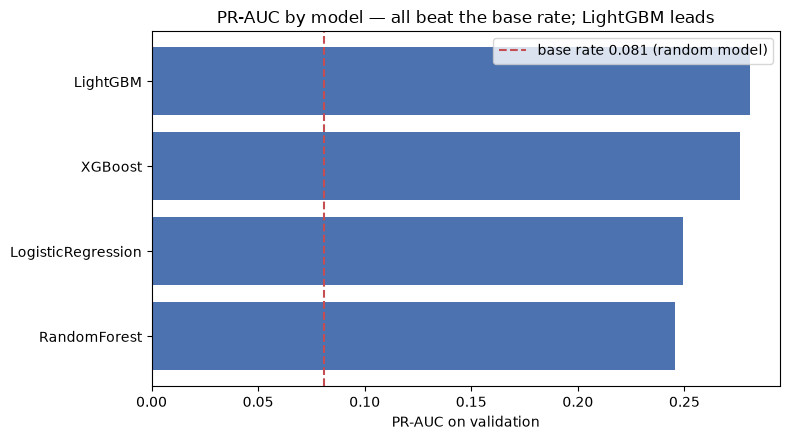

In [8]:
base_rate = y_valid.mean()
fig, ax = plt.subplots(figsize=(8, 4.5))
order = results_df.sort_values("PR_AUC").index
ax.barh(order, results_df.loc[order, "PR_AUC"], color="#4c72b0")
ax.axvline(base_rate, color="#c44e52", linestyle="--",
           label=f"base rate {base_rate:.3f} (random model)")
ax.set_xlabel("PR-AUC on validation")
ax.set_title("PR-AUC by model — all beat the base rate; LightGBM leads")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_model_pr_auc.png", dpi=120)
plt.show()

## 2 · Imbalance: class weights vs SMOTE (inside CV)

SMOTE must run inside each CV fold, never before the split, or synthetic rows leak into validation. An `imblearn` pipeline handles this correctly.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# class weights (no resampling)
weight_pipe = model.make_lgbm(spw, n_estimators=300)
weight_scores = cross_val_score(
    weight_pipe, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=-1)

# SMOTE inside the pipeline (fits per fold only)
smote_pipe = ImbPipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42)),
    ("clf", model.make_lgbm(1.0, n_estimators=300)),   # weight neutral; SMOTE balances
])
smote_scores = cross_val_score(
    smote_pipe, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=-1)

print("CV PR-AUC (5-fold):")
print(f"  class weights : {weight_scores.mean():.4f}  +/- {weight_scores.std():.4f}")
print(f"  SMOTE-in-CV   : {smote_scores.mean():.4f}  +/- {smote_scores.std():.4f}")

CV PR-AUC (5-fold):
  class weights : 0.2684  +/- 0.0061
  SMOTE-in-CV   : 0.2632  +/- 0.0064


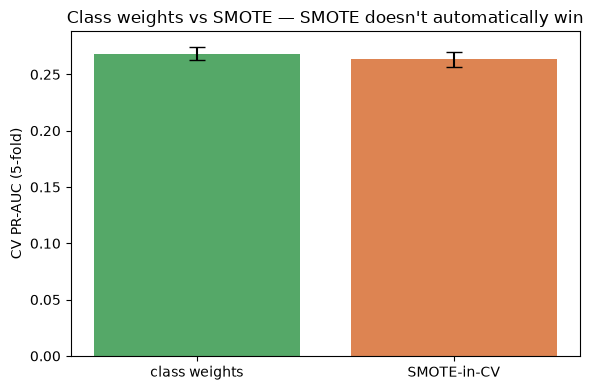

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
means = [weight_scores.mean(), smote_scores.mean()]
errs = [weight_scores.std(), smote_scores.std()]
ax.bar(["class weights", "SMOTE-in-CV"], means, yerr=errs, capsize=6,
       color=["#55a868", "#dd8452"])
ax.set_ylabel("CV PR-AUC (5-fold)")
ax.set_title("Class weights vs SMOTE — SMOTE doesn't automatically win")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_imbalance_strategy.png", dpi=120)
plt.show()

**Takeaway:** here plain class weights match or beat SMOTE — simpler and leak-proof — so we keep `scale_pos_weight`.

## 3 · How much does each satellite block add?

Start with application features, add each block, and watch PR-AUC on validation.

In [11]:
blocks = json.load(open("../data/processed/feature_blocks.json"))
stage_order = ["application", "bureau", "previous", "installments", "pos", "credit_card"]

lift = {}
used_cols = []
for stage in stage_order:
    used_cols = used_cols + blocks[stage]
    m = model.make_lgbm(spw, n_estimators=300)
    m.fit(X_train[used_cols], y_train)
    score = evaluate.pr_auc(y_valid, m.predict_proba(X_valid[used_cols])[:, 1])
    label = "application" if stage == "application" else f"+ {stage}"
    lift[label] = score
    print(f"{label:16s} features={len(used_cols):3d}  PR-AUC={score:.4f}")

application      features=172  PR-AUC=0.2584


+ bureau         features=183  PR-AUC=0.2676


+ previous       features=190  PR-AUC=0.2687


+ installments   features=195  PR-AUC=0.2767


+ pos            features=200  PR-AUC=0.2785


+ credit_card    features=204  PR-AUC=0.2805


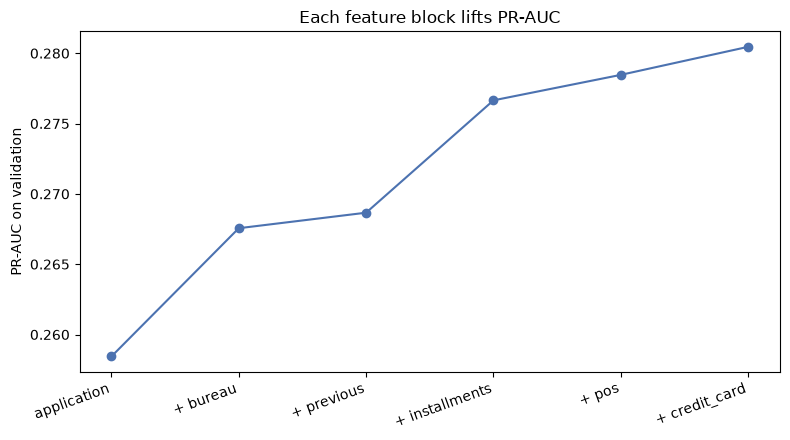

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(lift.keys()), list(lift.values()), marker="o", color="#4c72b0")
ax.set_ylabel("PR-AUC on validation")
ax.set_title("Each feature block lifts PR-AUC")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/11_feature_block_lift.png", dpi=120)
plt.show()

## 4 · Final model + save

Retrain LightGBM on the full training set and save it for the next phases.

In [13]:
final_model = model.make_lgbm(spw, n_estimators=400)
final_model.fit(X_train, y_train)

final_metrics = evaluate.evaluate_all(y_valid, final_model.predict_proba(X_valid)[:, 1])
print("Final LightGBM on validation:")
for k, v in final_metrics.items():
    print(f"  {k:8s} {v:.4f}")

joblib.dump(final_model, "../models/lgbm_model.joblib")
print("\nSaved -> models/lgbm_model.joblib")

Final LightGBM on validation:
  PR_AUC   0.2808
  ROC_AUC  0.7850
  Gini     0.5700
  KS       0.4289

Saved -> models/lgbm_model.joblib


## Takeaways

- **LightGBM wins** and becomes our model; all models beat the ~0.08 base rate.
- Class weights match or beat SMOTE here (SMOTE run inside CV folds).
- Every satellite block lifted PR-AUC.
- ROC-AUC ≈ 0.76–0.78 — a sane range (>0.90 would signal leakage).